# Toroidal VAE

In [1]:
import os
import sys
mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [2]:
%pwd
%load_ext autoreload
%autoreload 2

### Imports

In [3]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders as dataloaders
import lib.models as models
import lib.trainer as trainer
import lib.utils as utils
import lib.models.utils.save_load_models as modelutils



### Set up and initialize data loader

In [4]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Euclidean VAE

### Dataloader

In [5]:
batch_size = 64

dataloader = dataloaders.load_fashion_mnist(batch_size)
train_loader, test_loader = dataloader

### Model

In [11]:
data_dim = 784
latent_dim = 2
sftbeta = 1
device = "cpu"
encoder_width = 2
encoder_depth = 128
decoder_width = 2
decoder_depth = 128

model_config = {'data_dim': data_dim, 'latent_dim': latent_dim, 'sftbeta': sftbeta, 'device': device,
                'encoder_width': encoder_width, 'encoder_depth': encoder_depth, 'decoder_width': decoder_width,
                'decoder_depth': decoder_depth}

toroidal_model = models.ToroidalVAE(model_config)

### Optimizer

In [12]:
learning_rate = 0.001

toroidal_optimizer = optim.Adam(toroidal_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [13]:
num_epochs = 1
log_interval = 100
device = "cpu"

trainer_config = {'num_epochs': num_epochs, 'log_interval': log_interval, 'device': device}

toroidal_history = trainer.MVAETrainer(toroidal_model, dataloader, toroidal_optimizer, trainer_config).train()

Trainer successfully initialized.
Training the toroidalVAE model.
Starting epoch 1/1
Epoch [1/1], Step [100/938], Loss: 1.3364
Epoch [1/1], Step [200/938], Loss: 1.1200
Epoch [1/1], Step [300/938], Loss: 0.9330
Epoch [1/1], Step [400/938], Loss: 0.7506
Epoch [1/1], Step [500/938], Loss: 0.5302
Epoch [1/1], Step [600/938], Loss: 0.5298
Epoch [1/1], Step [700/938], Loss: 0.5190
Epoch [1/1], Step [800/938], Loss: 0.5135
Epoch [1/1], Step [900/938], Loss: 0.5092
Epoch 1/1, Train Loss: 0.0124, Test Loss: 0.0080
--------------------------------------------------


### Visualization 

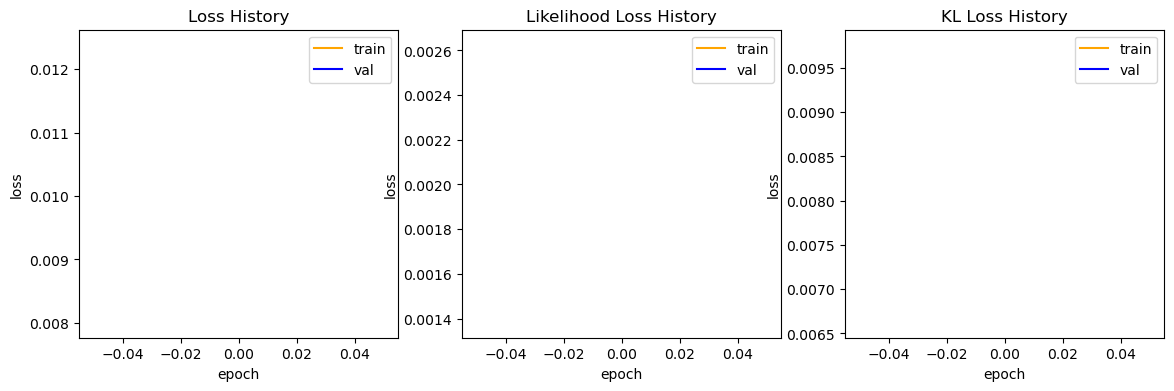

In [14]:
utils.show_training_history(toroidal_history)

### Save trained models

In [15]:
modelutils.save_model(toroidal_model, model_config)

Model saved as toroidal_1740058008.pth
Model saved as toroidal_1740058008.json


### Load pretrained models

In [16]:
#model = modelutils.load_model("gaussian_1740054584")
model = toroidal_model

### Visualizing the latent space

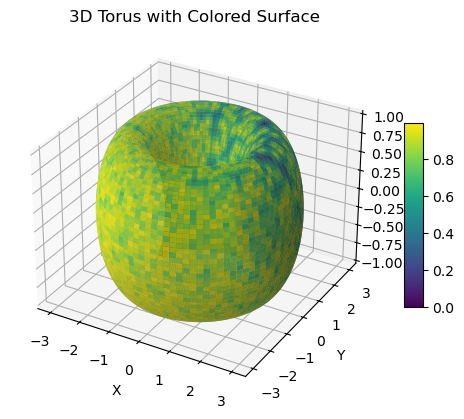

In [17]:
utils.plot_test_latents_on_torus(model, test_loader, device)

#### Visualize reconstructed mnist images

recon shape torch.Size([64, 1, 28, 28])
tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.,

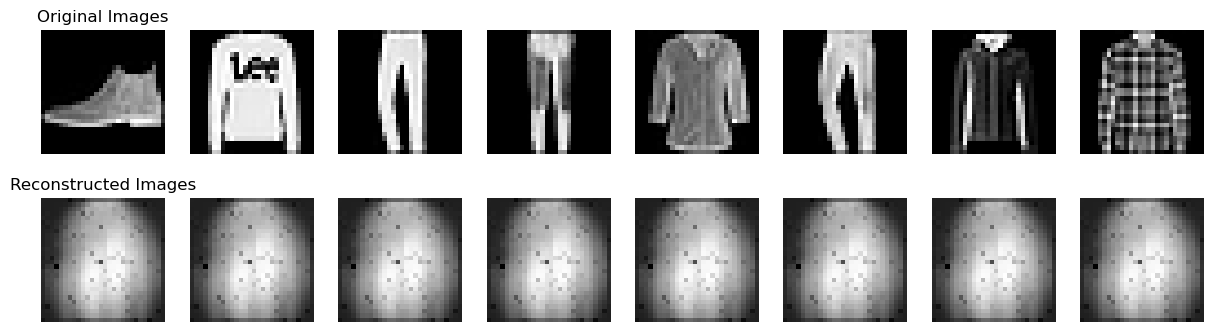

In [18]:
utils.show_recon_mnist(model, test_loader, device)